Interpolação polinomial
====
Dada uma tabela $T=\{(x_0,y_0), \cdots , (x_k,y_k)\}$ tal que $x_i \neq x_{j}$, se $i \neq j$. O **polinômio interpolador** da tabela é o único polinômio $p_T(x)$ de grau menor ou igual a $k$ que satisfaz
$$ p_T(x_i) = y_i $$ para todos os pontos $(x_i,y_i)$ da tabela. 

In [46]:
import numpy as np
from numpy.polynomial import polynomial as P

# teste de interpolação
x=[0,1,2,3,4]
y=[-2,1,0,-5,1]
p=P.polyfit(x,y,4) # Aproximação por ajustamento

In [ ]:
print(p)

[-2.     1.25   4.875 -3.75   0.625]


In [47]:
def f(x):
  return P.polyval(x, p)

In [48]:
f= lambda x : P.polyval(x,p)

In [ ]:
f(0)

-1.9999999999999933

-1.9999999999999933 0.9999999999999907 -2.4424906541753444e-14 -5.000000000000016 0.9999999999999516


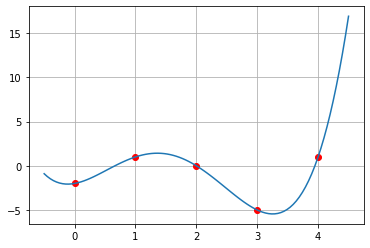

In [49]:
print(f(0),f(1),f(2),f(3),f(4)) # Aproximação por ajustamento (Método dos Mínimos Quadrados) não é exatamente o valor de f(x)

%matplotlib inline
from matplotlib.pyplot import plot,grid
plot(x,y, "ro")
t=np.linspace(-.5, 4.5,100) # Inicialização de t
plot(t,f(t))
grid()

Polinômio interpolador na forma de Lagrange
====
Definimos os polinômios de Lagrange $L_i(x)$ como
$L_i(x)=\prod_{j\neq i} \frac{(x-x_j)}{(x_i-x_j)}$
e neste caso o polinômio interpolador da tabela $T$ é dado por
$$ p_T(x)=\sum_{i=0}^{k}y_iL_i(x)$$

In [51]:
def Lagrange(i,t,x):
    '''Polinomios de Lagrange, t lista de pontos da tabela'''
    produto=1
    for j in range(len(t)):
        if (j!=i) :
            produto = produto*(x-t[j])/(t[i]-t[j])
    return produto
        

In [52]:
x #relembrando os valores de x

[0, 1, 2, 3, 4]

In [53]:
Lagrange(2,x,1) 
# Cálculo do coeficiente de lagrange para 
# o ponto X0 (parametro 0) dado
# o valor de domínio 2 (parametro 2) e 
# o vetor de pontos X0...Xk (parametro x)

0.0

In [54]:
g= lambda t : y[0]*Lagrange(0,x,t) + y[1]*Lagrange(1,x,t) + y[2]*Lagrange(2,x,t) + y[3]*Lagrange(3,x,t) + y[4]*Lagrange(4,x,t)


In [55]:
def g(t):
  return y[0]*Lagrange(0,x,t) + y[1]*Lagrange(1,x,t) + y[2]*Lagrange(2,x,t) + y[3]*Lagrange(3,x,t) + y[4]*Lagrange(4,x,t)

In [56]:
g1 = lambda t: sum([y[i]*Lagrange(i,x,t) for i in range(len(x))]) #Isso é equivalente a soma dos termos feito anteriormente

In [57]:
def g1(t):
  soma = 0
  for i in range(len(x)):
    soma = soma + y[i]*Lagrange(i,x,t)


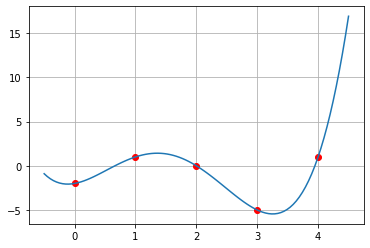

In [58]:
plot(x,y, "ro")
t=np.linspace(-.5, 4.5,100) # Inicialização de t
plot(t,g(t)) #Plot da interpolação de Lagrange, agora os resultados de f(x) são iguais a P(x)?
grid()

In [59]:
[g1(x[i])==y[i] for i in range(len(x))] # Agora sim temos P(x) == f(x)

[False, False, False, False, False]

In [60]:
print(g1(0),g1(1),g1(2),g1(3),g1(4))

None None None None None


#Usando lagrange de scipy

Em vez de calcularmos tudo do zero, no scipy, podemos usar a função lagrange diretamente para interpolar os dados. Vamos ver o exemplo a seguir


In [61]:
from scipy.interpolate import lagrange
import matplotlib.pyplot as plt

x = [0, 1, 2, 3]
y = [1, 3, 2, 0]

In [62]:
f = lagrange(x, y)

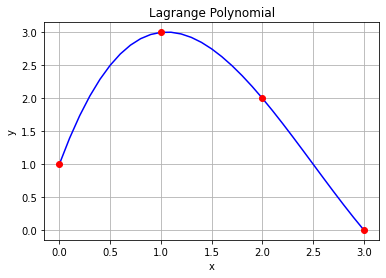

In [63]:
x_new = np.arange(0.0, 3.1, 0.1)
plt.plot(x_new, f(x_new), 'b', x, y, 'ro')
plt.title('Lagrange Polynomial')
plt.grid()
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [64]:
f(2.5) # Amostra da interpolação

0.9999999999999978

#Número de pontos e a interpolação

Considere a função a seguir para o intervalo [-1,1]

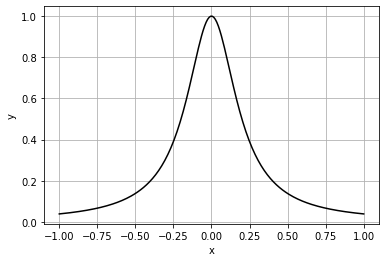

In [65]:
import numpy as np
from numpy.polynomial import polynomial as P
import matplotlib.pyplot as plt

f = lambda x: 1/(1+25 * x**2) # Function to be interpolated.

# teste de interpolação
x = np.linspace(-1,1,200)
y=f(x)

plt.plot(x, f(x),'k')
plt.grid()
plt.xlabel('x')
plt.ylabel('y')
plt.show()

Vamos aproximá-la usando 11 pontos (sinta-se a vontade para testar com outros valores). Note as caldas da interpolação

In [78]:
points = 11 # Esse valor pode ser alterado, note a diferença nas caldas da distribuição

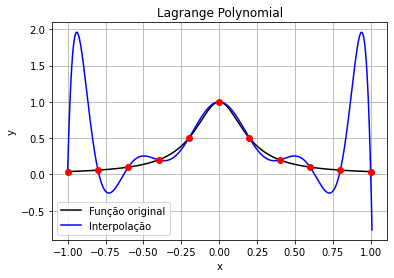

In [79]:
from scipy.interpolate import lagrange
import matplotlib.pyplot as plt
import numpy as np

f = lambda x: 1/(1+25 * x**2) # Function to be interpolated.

# teste de interpolação
x = np.linspace(-1,1,points) # Número de pontos para interpolar
y = f(x)

f_aproximada = lagrange(x, y)

x_new = np.arange(-1.0, 1.01, 0.001)
plt.plot(x_new, f(x_new),'k',x_new, f_aproximada(x_new), 'b', x, y, 'ro')
plt.legend(['Função original','Interpolação']) 
plt.title('Lagrange Polynomial')
plt.grid()
plt.xlabel('x')
plt.ylabel('y')
plt.show()

# Atividade Aplicada
A velocidade de um móvel foi registrada em intervalos com variação de 5 minutos em um
período de 45 minutos.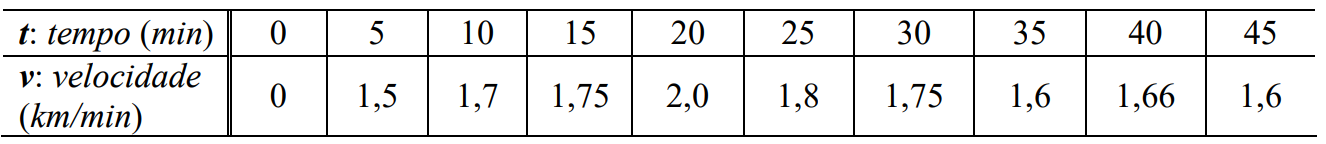

a) Obtenha, por interpolação polinomial de Lagrange, uma estimativa da velocidade do móvel aos 7 minutos, primeiro através de um polinômio de maior grau possível e, segundo, através de um polinômio de grau dois que seja coincidente com três registros próximos dos 7 minutos. Compare os resultados obtidos, confrontando-os graficamente e numericamente.

b) Obtenha, por interpolação polinomial de Lagrange, uma estimativa da velocidade do móvel aos 18 minutos, primeiro através de um polinômio de maior grau possível e, segundo, através de um polinômio de grau dois que seja coincidente com os três registros mais próximos dos 18 minutos. Compare os resultados obtidos, confrontando-os graficamente e numericamente.

c) Repita o processo para uma estimativa de velocidade aos 43 minutos.

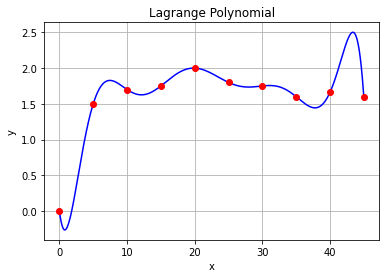

In [80]:
from scipy.interpolate import lagrange
import matplotlib.pyplot as plt
import numpy as np

# teste de interpolação
x = [0,5,10,15,20,25,30,35,40,45] # t: tempo (min)
y = [0,1.5,1.7,1.75,2,1.8,1.75,1.6,1.66,1.6] # v: velocidade (km/min)

f_aproximada = lagrange(x, y)

#fig = plt.figure(figsize = (10,8))
x_new = np.arange(0, 45, 0.01)
plt.plot(x_new, f_aproximada(x_new), 'b', x, y, 'ro')
plt.title('Lagrange Polynomial')
plt.grid()
plt.xlabel('x')
plt.ylabel('y')
plt.show()

a) Obtenha, por interpolação polinomial de Lagrange, uma estimativa da velocidade do móvel aos 7 minutos, primeiro através de um polinômio de maior grau possível e, segundo, através de um polinômio de grau dois que seja coincidente com três registros próximos dos 7 minutos. Compare os resultados obtidos, confrontando-os graficamente e numericamente.

Todos os pontos: 1.819012164608044
Apenas 3 pontos 1.736


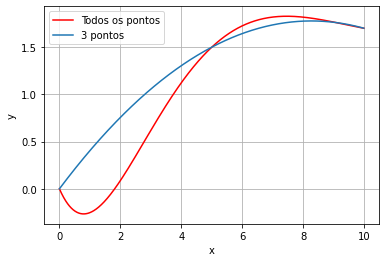

In [81]:
print('Todos os pontos:',f_aproximada(7))

xx = [0,5,10] # t: tempo (min)
yy = [0,1.5,1.7] # v: velocidade (km/min)

f_aproximada_3pts = lagrange(xx, yy)

print('Apenas 3 pontos', f_aproximada_3pts(7))

x_new = np.arange(0, 10, 0.01)
plt.plot(x_new,f_aproximada(x_new),'r',x_new,f_aproximada_3pts(x_new))
plt.legend(['Todos os pontos','3 pontos']) 
plt.grid()
plt.xlabel('x')
plt.ylabel('y')
plt.show()

b) Obtenha, por interpolação polinomial de Lagrange, uma estimativa da velocidade do móvel aos 18 minutos, primeiro através de um polinômio de maior grau possível e, segundo, através de um polinômio de grau dois que seja coincidente com os três registros mais próximos dos 18 minutos. Compare os resultados obtidos, confrontando-os graficamente e numericamente.

Todos os pontos: 1.9554750853094784
Apenas 3 pontos 1.953999999999994


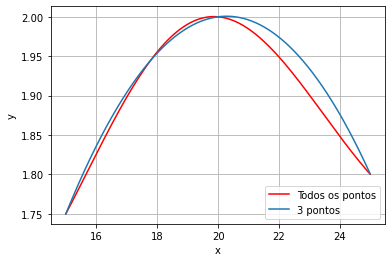

In [82]:
print('Todos os pontos:',f_aproximada(18))

xx = [15,20,25] # t: tempo (min)
yy = [1.75,2,1.8] # v: velocidade (km/min)

f_aproximada_3pts = lagrange(xx, yy)

print('Apenas 3 pontos', f_aproximada_3pts(18))

x_new = np.arange(15, 25, 0.01)
plt.plot(x_new,f_aproximada(x_new),'r',x_new,f_aproximada_3pts(x_new))
plt.legend(['Todos os pontos','3 pontos']) 
plt.grid()
plt.xlabel('x')
plt.ylabel('y')
plt.show()

c) Repita o processo para uma estimativa de velocidade aos 43 minutos.

Todos os pontos: 2.4728642433691297
Apenas 3 pontos 1.6383999999999652


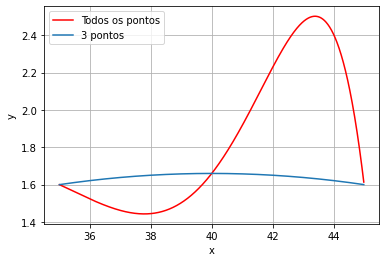

In [83]:
print('Todos os pontos:',f_aproximada(43))

xx = [35,40,45] # t: tempo (min)
yy = [1.6,1.66,1.6] # v: velocidade (km/min)

f_aproximada_3pts = lagrange(xx, yy)

print('Apenas 3 pontos', f_aproximada_3pts(43))

x_new = np.arange(35, 45, 0.01)
plt.plot(x_new,f_aproximada(x_new),'r',x_new,f_aproximada_3pts(x_new))
plt.legend(['Todos os pontos','3 pontos']) 
plt.grid()
plt.xlabel('x')
plt.ylabel('y')
plt.show()